In [ ]:
#3장
#3.1.1 K-최근접 이웃

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class'] # 데이터셋의 열 이름을 지정
dataset = pd.read_csv('../chap03/data/iris.data', names=names)

In [2]:
X = dataset.iloc[:, :-1].values # 데이터셋에서 마지막 열을 제외한 모든 열을 선택하여 X에 저장
y = dataset.iloc[:, 4].values # 데이터셋에서 마지막 열(클래스 레이블)을 선택하여 y에 저장

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20) # 데이터셋을 훈련 세트와 테스트 세트로 분할, 테스트 세트의 크기는 전체의 20%

In [3]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler() # StandardScaler 객체를 생성하여 s에 저장, 이 객체는 데이터의 평균을 0으로, 표준 편차를 1로 조정하는 데 사용됨

X_train = s.fit_transform(X_train) # 훈련 세트 X_train에 대해 StandardScaler를 적용하여 평균을 0으로, 표준 편차를 1로 조정한 결과를 X_train에 저장
X_test = s.fit_transform(X_test)

In [10]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=20) # KNeighborsClassifier 객체를 생성하여 knn에 저장, 이 객체는 K-최근접 이웃 알고리즘을 사용하여 분류 작업을 수행하는 데 사용됨, n_neighbors=50은 이웃의 수를 50으로 설정함
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=20)

In [11]:
from sklearn.metrics import accuracy_score
y_pred = knn.predict(X_test)
print("정확도: {}".format( accuracy_score(y_test, y_pred)))

정확도: 0.8666666666666667


In [16]:
k=100
acc_array=np.zeros(k) # 정확도를 저장할 배열을 생성, 크기는 k로 설정됨
for k in np.arange(1,k+1,1):  # 1부터 k까지의 정수에 대해 반복, 이 범위는 K-최근접 이웃 알고리즘에서 사용할 이웃의 수를 나타냄
    classifier = KNeighborsClassifier(n_neighbors=k).fit(X_train,y_train) 
    y_pred = classifier.predict(X_test)
    acc = metrics.accuracy_score(y_test, y_pred)
    acc_array[k-1]=acc 

max_acc=np.amax(acc_array)
acc_list=list(acc_array)
k=acc_list.index(max_acc)
print("정확도 ", max_acc, "으로 최적의 k는", k+1, "입니다.")

정확도  0.9333333333333333 으로 최적의 k는 5 입니다.


In [17]:
#3.1.2 서포트 벡터 머신(SVM)

In [38]:
from sklearn import svm
from sklearn import metrics
from sklearn import datasets
from sklearn import model_selection

import tensorflow as tf
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # TensorFlow의 로그 레벨을 설정하여 경고 메시지를 숨김, '3'은 모든 로그 메시지를 숨기는 것을 의미함

In [39]:
iris = datasets.load_iris()
x_train, x_test, y_train, y_test = model_selection.train_test_split(iris.data, 
                                                                    iris.target, 
                                                                    test_size=0.6, 
                                                                   random_state=42) # 데이터셋을 훈련 세트와 테스트 세트로 분할, 테스트 세트의 크기는 전체의 60%, random_state=42는 데이터 분할의 일관성을 위해 난수 시드를 설정함

In [40]:
svc_model = svm.SVC(kernel='linear', C=0.1, gamma=0.5) # SVC 객체를 생성하여 분류에 사용
svc_model.fit(x_train, y_train)
predictions = svc_model.predict(x_test)
score = metrics.accuracy_score(y_test, predictions)
print('정확도: {0:f}'.format(score))

정확도: 0.977778


In [12]:
#3.1.3 의사결정 트리

In [ ]:
import pandas as pd
df = pd.read_csv('../chap03/data/titanic/train.csv', index_col='PassengerId') # CSV 파일을 읽어와서 DataFrame으로 저장, 'PassengerId' 열을 인덱스로 사용하여 df에 저장
print(df.head())

             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   

             SibSp  Parch            Ticket     Fare Cabin Embarked  
PassengerId                                                          
1                1      0         A/5 21171   7.2500   NaN        S

In [42]:
df = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']]
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = df.dropna() 
X = df.drop('Survived', axis=1)
y = df['Survived']

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [44]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

In [45]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [46]:
y_predict = model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predict)

0.8156424581005587

In [ ]:
from sklearn.metrics import confusion_matrix # 혼동 행렬을 계산하는 함수인 confusion_matrix를 sklearn.metrics에서 가져옴
pd.DataFrame( # 혼동 행렬을 DataFrame으로 변환하여 시각적으로 표현, confusion_matrix(y_test, y_predict)는 실제 레이블과 예측 레이블을 비교하여 혼동 행렬을 계산함, columns는 열 이름을 지정하고 index는 행 이름을 지정함. 여기에서 1종 에러는 실제 생존자(True Survival)를 사망자로 잘못 예측하는 경우이고, 2종 에러는 실제 사망자(True Not Survival)를 생존자로 잘못 예측하는 경우임
    confusion_matrix(y_test, y_predict),
    columns=['Predicted Not Survival', 'Predicted Survival'],
    index=['True Not Survival', 'True Survival']
)

,Predicted Not Survival,Predicted Survival
True Not Survival,97,15
True Survival,18,49


In [20]:
#3.1.4 로지스틱 회귀

In [2]:
%matplotlib inline
from sklearn.datasets import load_digits
digits = load_digits() # 손글씨 숫자 데이터셋을 로드하여 digits에 저장, 이 데이터셋은 8x8 픽셀로 구성된 손글씨 숫자 이미지와 해당 레이블로 구성되어 있음
print("Image Data Shape" , digits.data.shape) # digits.data는 손글씨 숫자 이미지 데이터를 포함하는 배열로, 각 행은 하나의 이미지에 해당하며, 각 열은 이미지의 픽셀 값을 나타냄. digits.data.shape는 이 배열의 형태를 반환하여 이미지 데이터의 크기와 차원을 보여줌
print("Label Data Shape", digits.target.shape) # digits.target은 손글씨 숫자의 레이블을 포함하는 배열로, 각 요소는 해당 이미지의 숫자 값을 나타냄. digits.target.shape는 이 배열의 형태를 반환하여 레이블 데이터의 크기와 차원을 보여줌

Image Data Shape (1797, 64)
Label Data Shape (1797,)


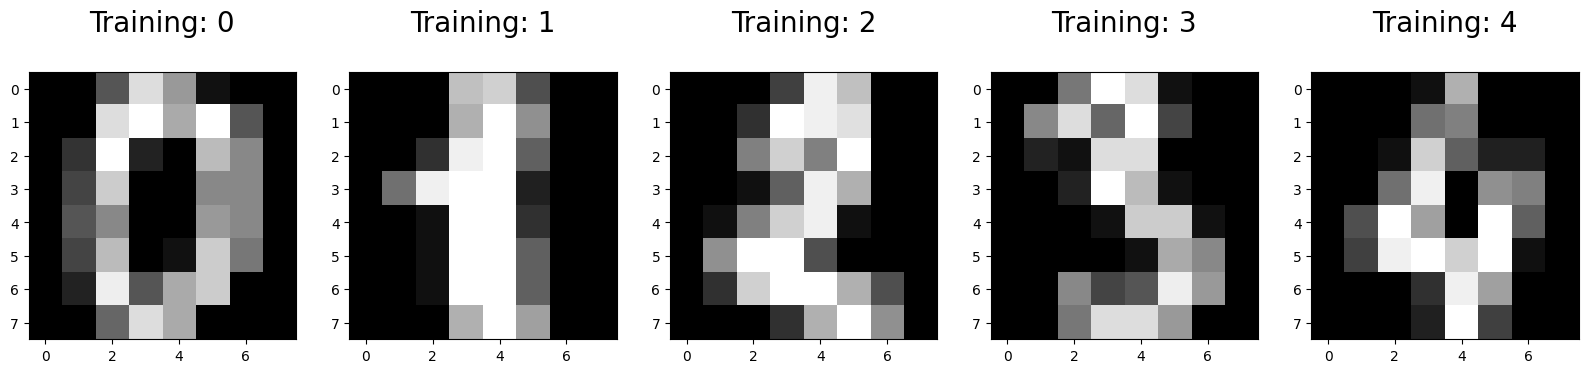

In [3]:
import numpy as np 
import matplotlib.pyplot as plt

plt.figure(figsize=(20,4)) # 그래프의 크기를 가로 20인치, 세로 4인치로 설정하여 여러 이미지를 한 줄에 나란히 표시할 수 있도록 함
for index, (image, label) in enumerate(zip(digits.data[0:5], digits.target[0:5])): # digits.data[0:5]는 손글씨 숫자 이미지 데이터의 처음 5개를 선택하고, digits.target[0:5]는 해당 이미지의 레이블을 선택함. zip 함수를 사용하여 이미지와 레이블을 함께 반복하면서 index는 반복 횟수를 나타냄
    plt.subplot(1, 5, index + 1) # 그래프를 1행 5열로 나누고, index + 1 번째 위치에 현재 이미지를 표시하도록 설정함. index는 0부터 시작하므로 index + 1을 사용하여 그래프의 위치를 지정함
    plt.imshow(np.reshape(image, (8,8)), cmap=plt.cm.gray) # image는 64개의 픽셀 값을 포함하는 1차원 배열이므로, np.reshape(image, (8,8))을 사용하여 8x8 형태의 2차원 배열로 변환함. plt.imshow()는 이 배열을 이미지로 표시하며, cmap=plt.cm.gray는 이미지를 회색조로 표시하도록 설정함
    plt.title('Training: %i\n' % label, fontsize = 20) # 그래프의 제목을 설정하여 각 이미지가 어떤 숫자를 나타내는지 표시함. 'Training: %i\n' % label은 문자열 포맷팅을 사용하여 label 값을 제목에 포함시키며, fontsize=20은 제목의 글꼴 크기를 20으로 설정함

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    digits.data,
    digits.target,
    test_size=0.25,
    random_state=0,
    stratify=digits.target
)

# 실습용: 학습 시간을 줄이기 위해 훈련 데이터 일부만 사용
x_train, _, y_train, _ = train_test_split(
    x_train,
    y_train,
    train_size=0.3,
    random_state=0,
    stratify=y_train
)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 스케일링을 함께 적용하면 낮은 max_iter에서도 수렴이 훨씬 안정적입니다.
logisticRegr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=50, solver='liblinear', random_state=0)
 )
logisticRegr.fit(x_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=50, random_state=0,
                                    solver='liblinear'))])

In [11]:
logisticRegr.predict(x_test[0].reshape(1,-1))
logisticRegr.predict(x_test[0:10])

array([2, 0, 4, 9, 4, 8, 2, 4, 6, 7])

In [12]:
predictions = logisticRegr.predict(x_test)
score = logisticRegr.score(x_test, y_test)
print(score)

0.9444444444444444


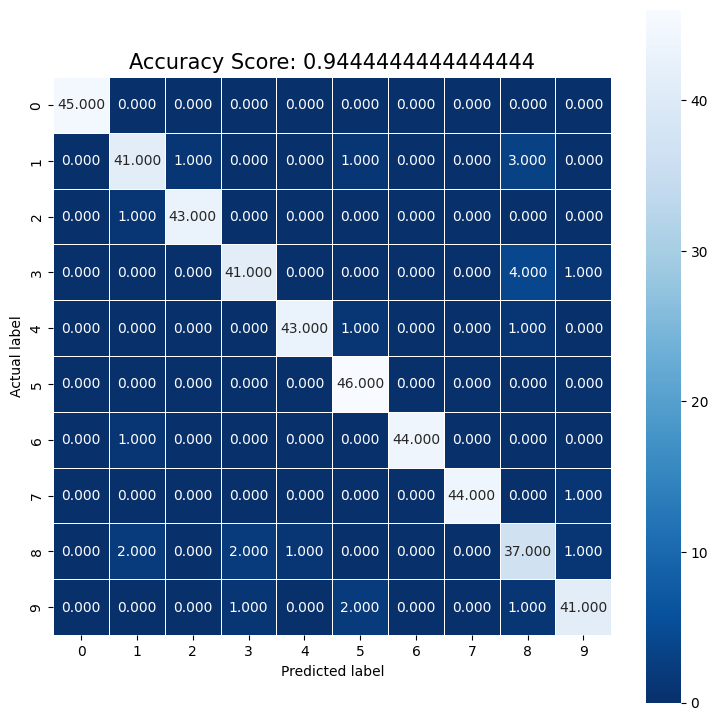

In [13]:
import numpy as np 
import seaborn as sns
from sklearn import metrics

cm = metrics.confusion_matrix(y_test, predictions)
plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(score)
plt.title(all_sample_title, size = 15);
plt.show();

In [27]:
#3.1.4 선형 회귀

In [14]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as seabornInstance 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline

In [15]:
dataset = pd.read_csv('../chap03/data/weather.csv')

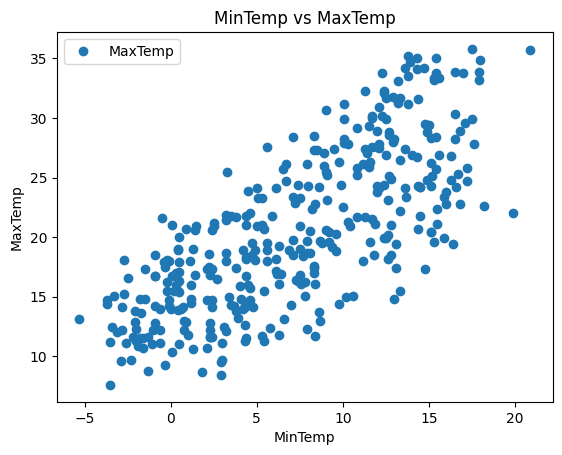

In [17]:
dataset.plot(x='MinTemp', y='MaxTemp', style='o')  
plt.title('MinTemp vs MaxTemp')  
plt.xlabel('MinTemp')  
plt.ylabel('MaxTemp') 
plt.show()

In [18]:
X = dataset['MinTemp'].values.reshape(-1,1)
y = dataset['MaxTemp'].values.reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [19]:
y_pred = regressor.predict(X_test)
df = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_pred.flatten()})
df

,Actual,Predicted
0,25.2,23.413030
1,11.5,13.086857
2,21.1,27.264856
3,22.2,25.461874
4,20.4,26.937041
...,...,...
69,18.9,20.216833
70,22.8,27.674625
71,16.1,21.446140
72,25.1,24.970151


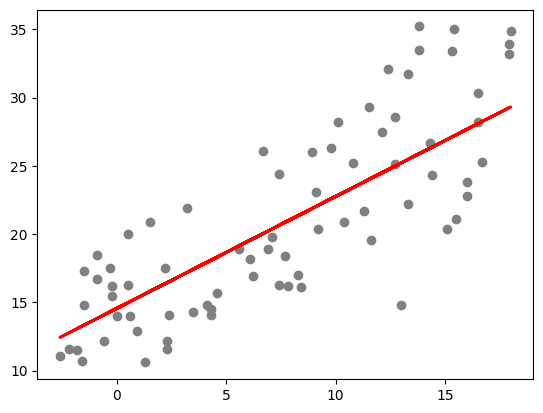

In [20]:
plt.scatter(X_test, y_test,  color='gray')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.show()

In [21]:
print('평균제곱법:', metrics.mean_squared_error(y_test, y_pred))  
print('루트 평균제곱법:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

평균제곱법: 17.011877668640622
루트 평균제곱법: 4.124545753006096


In [36]:
#3.2.1 K=평균 군집화

In [37]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [38]:
data = pd.read_csv('../chap03/data/sales data.csv')
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [39]:
categorical_features = ['Channel', 'Region']
continuous_features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

for col in categorical_features:
    dummies = pd.get_dummies(data[col], prefix=col)
    data = pd.concat([data, dummies], axis=1)
    data.drop(col, axis=1, inplace=True)
data.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_1,Channel_2,Region_1,Region_2,Region_3
0,12669,9656,7561,214,2674,1338,0,1,0,0,1
1,7057,9810,9568,1762,3293,1776,0,1,0,0,1
2,6353,8808,7684,2405,3516,7844,0,1,0,0,1
3,13265,1196,4221,6404,507,1788,1,0,0,0,1
4,22615,5410,7198,3915,1777,5185,0,1,0,0,1


In [40]:
mms = MinMaxScaler()
mms.fit(data)
data_transformed = mms.transform(data)

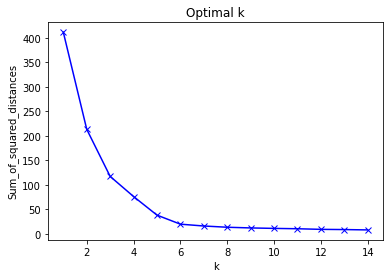

In [41]:
mms = MinMaxScaler()
mms.fit(data)
data_transformed = mms.transform(data)

Sum_of_squared_distances = []
K = range(1,15)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(data_transformed)
    Sum_of_squared_distances.append(km.inertia_)

plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Optimal k')
plt.show()

In [42]:
#3.2.3 PCA

In [43]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
  
from sklearn.cluster import DBSCAN 
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import normalize 
from sklearn.decomposition import PCA

In [44]:
X = pd.read_csv('../chap03/data/credit card.csv') 
X = X.drop('CUST_ID', axis = 1) 
X.fillna(method ='ffill', inplace = True) 
print(X.head())

       BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0    40.900749           0.818182      95.40              0.00   
1  3202.467416           0.909091       0.00              0.00   
2  2495.148862           1.000000     773.17            773.17   
3  1666.670542           0.636364    1499.00           1499.00   
4   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000                          0.000000   
2                

In [45]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_normalized = normalize(X_scaled) 
X_normalized = pd.DataFrame(X_normalized)
pca = PCA(n_components = 2)
X_principal = pca.fit_transform(X_normalized)
X_principal = pd.DataFrame(X_principal) 
X_principal.columns = ['P1', 'P2'] 
print(X_principal.head())

         P1        P2
0 -0.489949 -0.679976
1 -0.519099  0.544827
2  0.330633  0.268880
3 -0.481657 -0.097610
4 -0.563512 -0.482506


In [46]:
db_default = DBSCAN(eps = 0.0375, min_samples = 3).fit(X_principal)
labels = db_default.labels_

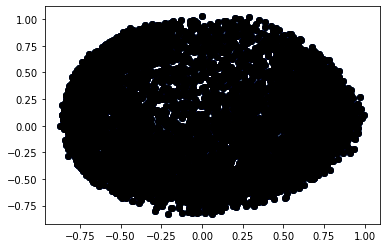

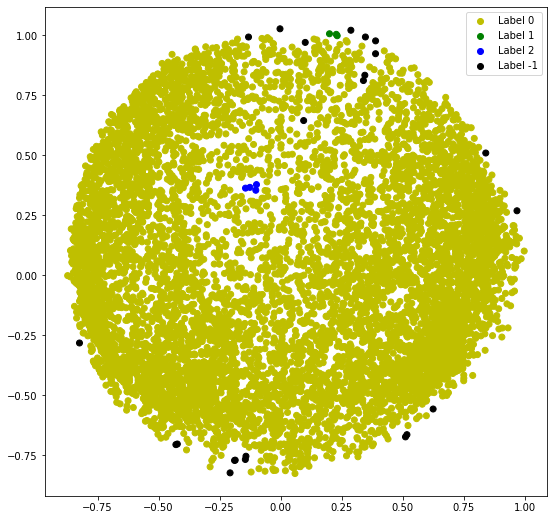

In [47]:
colours = {} 
colours[0] = 'y'
colours[1] = 'g'
colours[2] = 'b'
colours[-1] = 'k'
  
cvec = [colours[label] for label in labels]
  
r = plt.scatter(X_principal['P1'], X_principal['P2'], color ='y'); 
g = plt.scatter(X_principal['P1'], X_principal['P2'], color ='g'); 
b = plt.scatter(X_principal['P1'], X_principal['P2'], color ='b'); 
k = plt.scatter(X_principal['P1'], X_principal['P2'], color ='k'); 
  
plt.figure(figsize =(9, 9)) 
plt.scatter(X_principal['P1'], X_principal['P2'], c = cvec) 
  
plt.legend((r, g, b, k), ('Label 0', 'Label 1', 'Label 2', 'Label -1'))
plt.show()

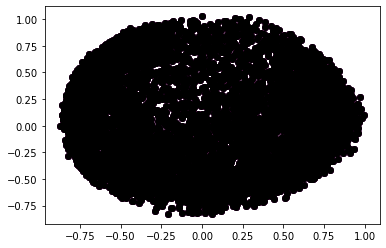

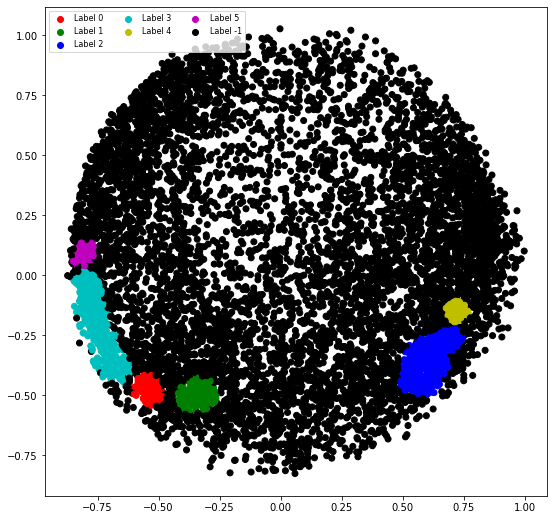

In [48]:
db = DBSCAN(eps = 0.0375, min_samples = 50).fit(X_principal) 
labels1 = db.labels_

colours1 = {} 
colours1[0] = 'r'
colours1[1] = 'g'
colours1[2] = 'b'
colours1[3] = 'c'
colours1[4] = 'y'
colours1[5] = 'm'
colours1[-1] = 'k'
  
cvec = [colours1[label] for label in labels1] 
colors1 = ['r', 'g', 'b', 'c', 'y', 'm', 'k' ] 
  
r = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[0]) 
g = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[1]) 
b = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[2]) 
c = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[3]) 
y = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[4]) 
m = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[5]) 
k = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[6]) 
  
plt.figure(figsize =(9, 9)) 
plt.scatter(X_principal['P1'], X_principal['P2'], c = cvec) 
plt.legend((r, g, b, c, y, m, k), 
           ('Label 0', 'Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label -1'), 
           scatterpoints = 1, 
           loc ='upper left', 
           ncol = 3, 
           fontsize = 8) 
plt.show()


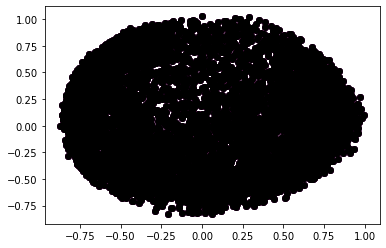

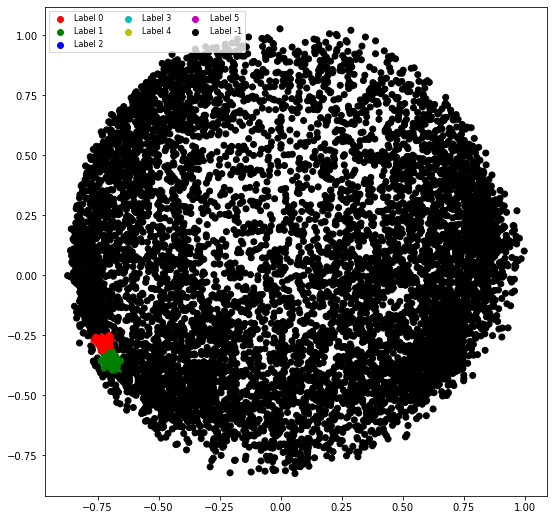

In [49]:
db = DBSCAN(eps = 0.0375, min_samples = 100).fit(X_principal)
labels1 = db.labels_

colours1 = {} 
colours1[0] = 'r'
colours1[1] = 'g'
colours1[2] = 'b'
colours1[3] = 'c'
colours1[4] = 'y'
colours1[5] = 'm'
colours1[-1] = 'k'
  
cvec = [colours1[label] for label in labels1] 
colors1 = ['r', 'g', 'b', 'c', 'y', 'm', 'k' ] 
  
r = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[0]) 
g = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[1]) 
b = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[2]) 
c = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[3]) 
y = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[4]) 
m = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[5]) 
k = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[6]) 
  
plt.figure(figsize =(9, 9)) 
plt.scatter(X_principal['P1'], X_principal['P2'], c = cvec) 
plt.legend((r, g, b, c, y, m, k), 
           ('Label 0', 'Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label -1'), 
           scatterpoints = 1, 
           loc ='upper left', 
           ncol = 3, 
           fontsize = 8) 
plt.show()
